In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys

# Make sure notebook can import from src folder
sys.path.append(os.path.abspath("../src"))

# Plotting defaults
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")

In [2]:
from data_pipeline.loaders import load_standardized_options, load_option_volume_wrds

px  = load_standardized_options("spy")
vol = load_option_volume_wrds("spy")

print("px cols:", px.columns.tolist()[:12])
display(px.head())

print("vol cols:", vol.columns.tolist()[:12])
display(vol.head())

px cols: ['date', 'underlying', 'put_call', 'expiry', 'strike', 'mid', 'last', 'iv', 'delta', 'gamma', 'vega', 'theta']


,date,underlying,put_call,expiry,strike,mid,last,iv,delta,gamma,vega,theta
0,2005-01-10,SPY,C,2005-01-20,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
1,2005-01-10,SPY,P,2005-01-20,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
2,2005-01-10,SPY,C,2005-02-09,119.203780,1.622029,1.622029,0.119222,0.506618,0.097998,13.604388,-11.076229
3,2005-01-10,SPY,P,2005-02-09,119.203780,1.651591,1.651591,0.120288,-0.499060,0.099202,13.573627,-8.884660
4,2005-01-10,SPY,C,2005-03-11,119.479045,2.329275,2.329275,0.121075,0.509576,0.068224,19.235642,-8.500341


vol cols: ['date', 'underlying', 'put_call', 'open_interest', 'volume']


,date,underlying,put_call,open_interest,volume
0,2005-01-10,SPY,NaN,0,241024
1,2005-01-10,SPY,C,0,131377
2,2005-01-10,SPY,P,0,109647
3,2005-01-11,SPY,NaN,217967,155058
4,2005-01-11,SPY,C,116214,72655


All raw files present & materialized 
SPY has many NaNs — verify source file/columns. Proceeding anyway.
Market daily shape: (27660, 4)


,close_spy,close_gspc,vix,rate_10y
date,,,,
2025-09-21,NaN,NaN,15.45,4.14
2025-09-22,NaN,NaN,16.10,4.15
2025-09-23,NaN,NaN,16.64,4.12
2025-09-24,NaN,NaN,16.18,4.16
2025-09-25,NaN,NaN,16.74,NaN


Options snapshot shape: (103246, 14)


,date,underlying,put_call,expiry,strike,mid,last,iv,delta,gamma,vega,theta,open_interest,volume
0,2005-01-10,SPY,C,2005-01-20,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,131377.0
1,2005-01-10,SPY,P,2005-01-20,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,109647.0
2,2005-01-10,SPY,C,2005-02-09,119.203780,1.622029,1.622029,0.119222,0.506618,0.097998,13.604388,-11.076229,0.0,131377.0
3,2005-01-10,SPY,P,2005-02-09,119.203780,1.651591,1.651591,0.120288,-0.499060,0.099202,13.573627,-8.884660,0.0,109647.0
4,2005-01-10,SPY,C,2005-03-11,119.479045,2.329275,2.329275,0.121075,0.509576,0.068224,19.235642,-8.500341,0.0,131377.0


Vol surface shape: (1706460, 5)


,date,underlying,tenor_d,moneyness,iv
0,2005-01-10,SPY,30,-90,0.171916
1,2005-01-10,SPY,30,-85,0.142588
2,2005-01-10,SPY,30,-80,0.122542
3,2005-01-10,SPY,30,-75,0.116218
4,2005-01-10,SPY,30,-70,0.115786


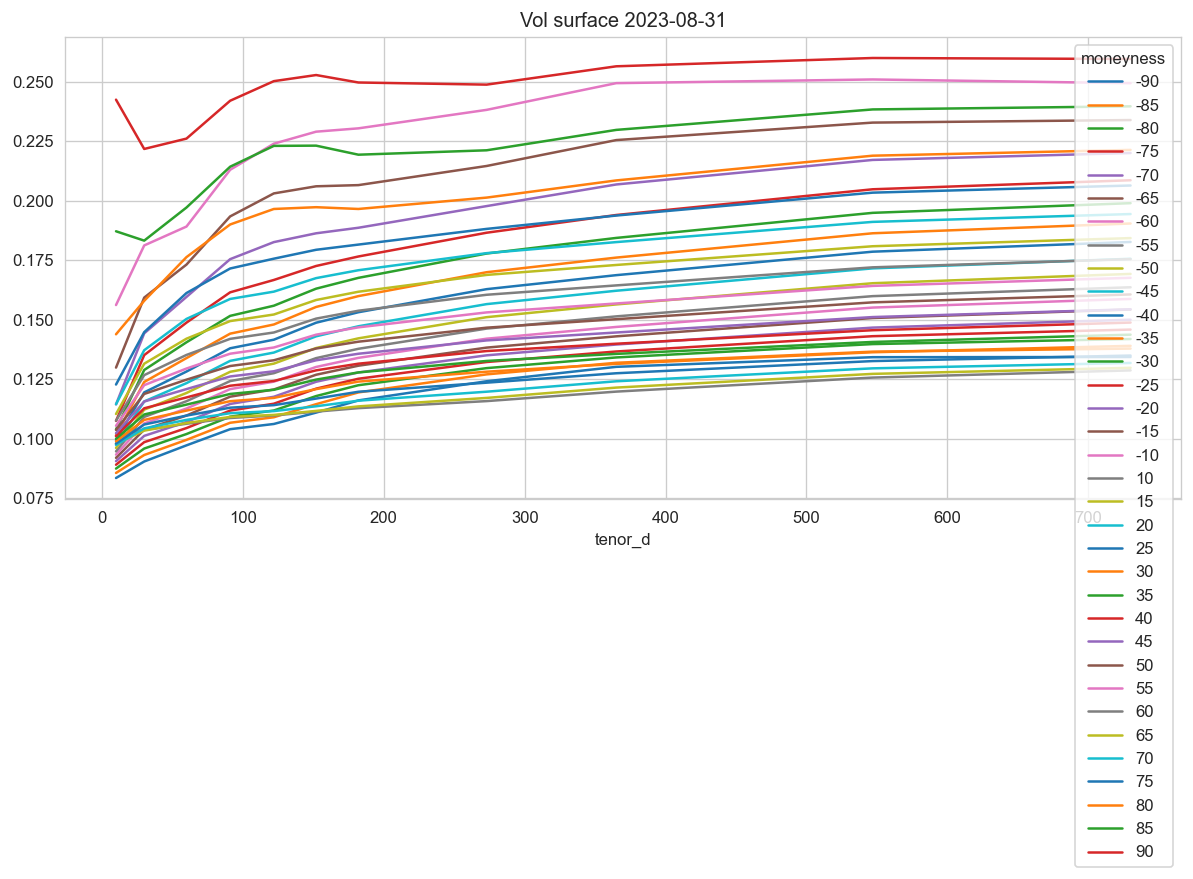

In [3]:

# --- setup ---
import pandas as pd
import matplotlib.pyplot as plt

from data_pipeline.validate import validate_raw
from data_pipeline.builders import (
    build_market_daily,
    build_options_snapshot,
    build_vol_surface_long,
    build_market_plus_hvol_fwd,
)

# --- 0) check LFS files are materialized ---
validate_raw()   # will error if someone forgot `git lfs pull`

# --- 1) macro/market series ---
mkt = build_market_daily(save=False)
print("Market daily shape:", mkt.shape)
display(mkt.tail())

# --- 2) options snapshot (SPY) ---
opt_spy = build_options_snapshot("spy", save=False)
print("Options snapshot shape:", opt_spy.shape)
display(opt_spy.head())

# --- 3) vol surface (SPY) ---
surf_spy = build_vol_surface_long("spy", save=False)
print("Vol surface shape:", surf_spy.shape)
display(surf_spy.head())

# pivot tenor vs moneyness for the latest date
d0 = surf_spy['date'].max()
surf0 = surf_spy.query("date == @d0").pivot(
    index='tenor_d', columns='moneyness', values='iv'
)
surf0.plot(title=f"Vol surface {d0.date()}", figsize=(12,5))
plt.show()

In [4]:
opt_spy.head(3)

,date,underlying,put_call,expiry,strike,mid,last,iv,delta,gamma,vega,theta,open_interest,volume
0,2005-01-10,SPY,C,2005-01-20,0.00000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,131377.0
1,2005-01-10,SPY,P,2005-01-20,0.00000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,109647.0
2,2005-01-10,SPY,C,2005-02-09,119.20378,1.622029,1.622029,0.119222,0.506618,0.097998,13.604388,-11.076229,0.0,131377.0


In [5]:
from data_pipeline.qc import coverage, assert_min_coverage

# --- ensure required columns exist ---
required = ["spy", "rate_10y"]

# try to find a plausible spot column and alias it to 'spy' if missing
if "spy" not in mkt.columns:
    spot_candidates = ["close", "adj_close", "px_close", "price", "spot", "spy_close"]
    spot_col = next((c for c in spot_candidates if c in mkt.columns), None)
    if spot_col is not None:
        mkt = mkt.copy()
        mkt["spy"] = mkt[spot_col]
        print(f"Aliased spot column '{spot_col}' -> 'spy'")
    else:
        print("Could not find a spot column to alias to 'spy'. Available cols:", list(mkt.columns)[:15])

# gentle notice if 10y rate is missing
if "rate_10y" not in mkt.columns:
    print(" 'rate_10y' not found in mkt columns. QC will likely fail this requirement.")

# --- run coverage + assertion ---
cov = coverage(mkt)
print("Coverage summary:\n", cov)

# only assert for the columns that actually exist to avoid hard crashes
existing_required = [c for c in required if c in mkt.columns]
if existing_required:
    assert_min_coverage(mkt, existing_required, 0.60)
    print(f"Minimum coverage OK for: {existing_required} (>= 60%)")
else:
    print("None of the required columns were present; skipped assert_min_coverage.")

Could not find a spot column to alias to 'spy'. Available cols: ['close_spy', 'close_gspc', 'vix', 'rate_10y']
Coverage summary:
                           first                 last non_na_ratio   rows
close_spy   1993-01-29 00:00:00  2025-09-11 00:00:00      0.43073  27660
close_gspc  1950-01-03 00:00:00  2025-09-11 00:00:00     0.999494  27660
vix         1990-01-02 00:00:00  2025-09-25 00:00:00     0.471837  27660
rate_10y    1962-01-02 00:00:00  2025-09-24 00:00:00      0.84154  27660
Minimum coverage OK for: ['rate_10y'] (>= 60%)


In [6]:
# --- robust column detection ---
def pick_col(df, candidates):
    return next((c for c in candidates if c in df.columns), None)

spy_col  = pick_col(mkt, ["spy","close_spy","spot","close","adj_close","px_close"])
gspc_col = pick_col(mkt, ["close_gspc","spx","gspc","^GSPC","px_spx","close_spx"])
vix_col  = pick_col(mkt, ["vix","vix_close","iv_30d","implied_vol"])
rate_col = pick_col(mkt, ["rate_10y","ust10y","t10y","yield_10y"])

print("Detected columns:", {"spy": spy_col, "gspc": gspc_col, "vix": vix_col, "rate_10y": rate_col})

# rows where at least one series has data
mkt_any = mkt[mkt.notna().any(axis=1)]

# rows where ALL detected series are present
present_required = [c for c in [spy_col, gspc_col, vix_col, rate_col] if c is not None]
mkt_all = mkt.dropna(subset=present_required) if present_required else mkt.copy()

# start from the first valid SPY point (if we found a spy column)
if spy_col is not None and mkt[spy_col].first_valid_index() is not None:
    mkt_from_spy = mkt.loc[mkt[spy_col].first_valid_index():]
else:
    mkt_from_spy = mkt.copy()

print("Shapes:", {"mkt_any": mkt_any.shape, "mkt_all": mkt_all.shape, "mkt_from_spy": mkt_from_spy.shape})

Detected columns: {'spy': 'close_spy', 'gspc': 'close_gspc', 'vix': 'vix', 'rate_10y': 'rate_10y'}
Shapes: {'mkt_any': (27660, 4), 'mkt_all': (11914, 4), 'mkt_from_spy': (11928, 4)}


In [7]:
mkt_all.head(3)

,close_spy,close_gspc,vix,rate_10y
date,,,,
1993-01-29,24.313038,438.779999,12.42,6.39
1993-01-30,24.313038,438.779999,12.42,6.39
1993-01-31,24.313038,438.779999,12.42,6.39


In [8]:
print("Vol surface shape:", surf_spy.shape)
print("Columns:", surf_spy.columns.tolist())
display(surf_spy.head())

print("\nNaN counts:")
display(surf_spy.isna().sum())

print("\nUnique tenors (days):", surf_spy['tenor_d'].unique()[:10])
print("Unique moneyness (sample):", surf_spy['moneyness'].unique()[:10])

Vol surface shape: (1706460, 5)
Columns: ['date', 'underlying', 'tenor_d', 'moneyness', 'iv']


,date,underlying,tenor_d,moneyness,iv
0,2005-01-10,SPY,30,-90,0.171916
1,2005-01-10,SPY,30,-85,0.142588
2,2005-01-10,SPY,30,-80,0.122542
3,2005-01-10,SPY,30,-75,0.116218
4,2005-01-10,SPY,30,-70,0.115786



NaN counts:


date          0
underlying    0
tenor_d       0
moneyness     0
iv            0
dtype: int64


Unique tenors (days): [ 30  60  91 122 152 182 273 365 547 730]
Unique moneyness (sample): [-90 -85 -80 -75 -70 -65 -60 -55 -50 -45]


In [9]:
# speed knobs
LAST_N_DAYS = 730  # 2 years; bump up/down as needed

# ensure datetime and filter recent window
opt_spy_fast = opt_spy.copy()
opt_spy_fast["date"] = pd.to_datetime(opt_spy_fast["date"], errors="coerce")
cutoff = opt_spy_fast["date"].max() - pd.Timedelta(days=LAST_N_DAYS)
opt_spy_fast = opt_spy_fast.loc[opt_spy_fast["date"] >= cutoff]

# keep only sensible rows for Greeks/prices
opt_spy_fast = opt_spy_fast[(opt_spy_fast["mid"] > 0) & opt_spy_fast["iv"].notna()]

# aggregate to daily medians by put/call (massive downsample)
agg_cols = ["mid", "iv", "delta", "gamma", "theta", "vega"]
daily = (
    opt_spy_fast
    .groupby(["date", "put_call"], as_index=False)[agg_cols]
    .median()
    .sort_values("date")
)
daily.head()

,date,put_call,mid,iv,delta,gamma,theta,vega
0,2021-08-31,C,19.623375,0.166622,0.531496,0.008429,-23.277608,114.865131
1,2021-08-31,P,19.405842,0.167870,-0.475931,0.008098,-23.736277,115.491141
2,2021-09-01,C,19.485111,0.165219,0.532320,0.008537,-22.565432,114.667552
3,2021-09-01,P,19.310162,0.167143,-0.475488,0.008121,-24.189450,115.426829
4,2021-09-02,C,19.409909,0.164155,0.532020,0.008569,-22.535528,115.570345


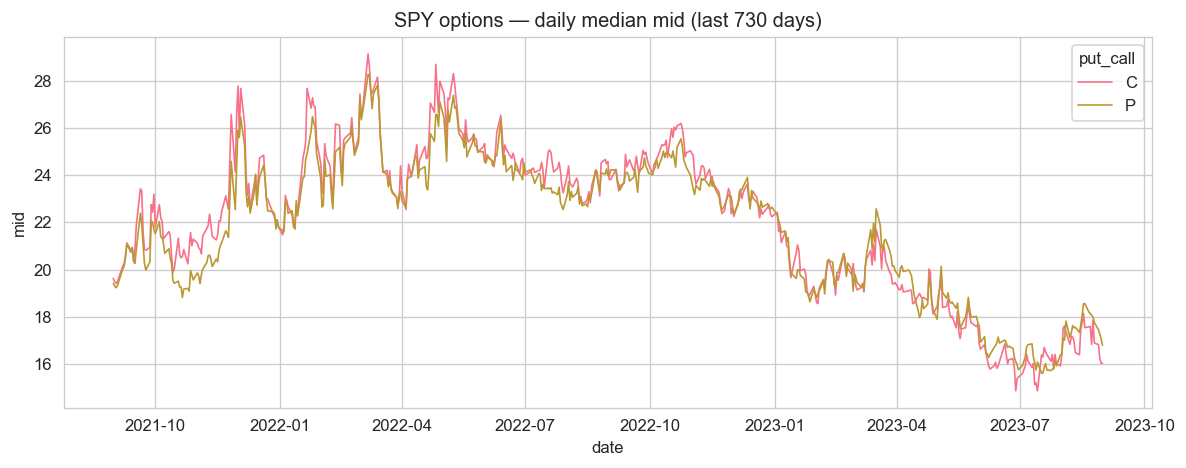

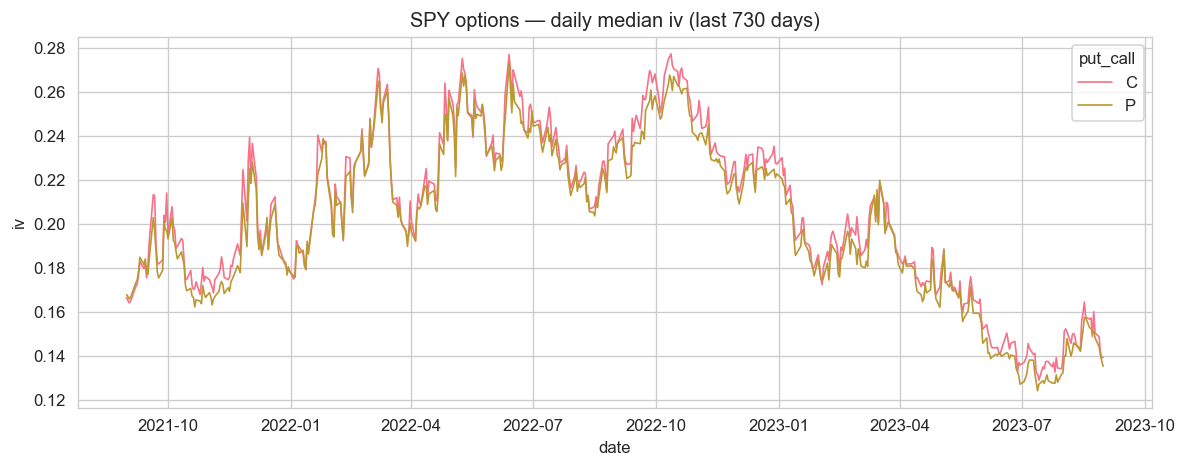

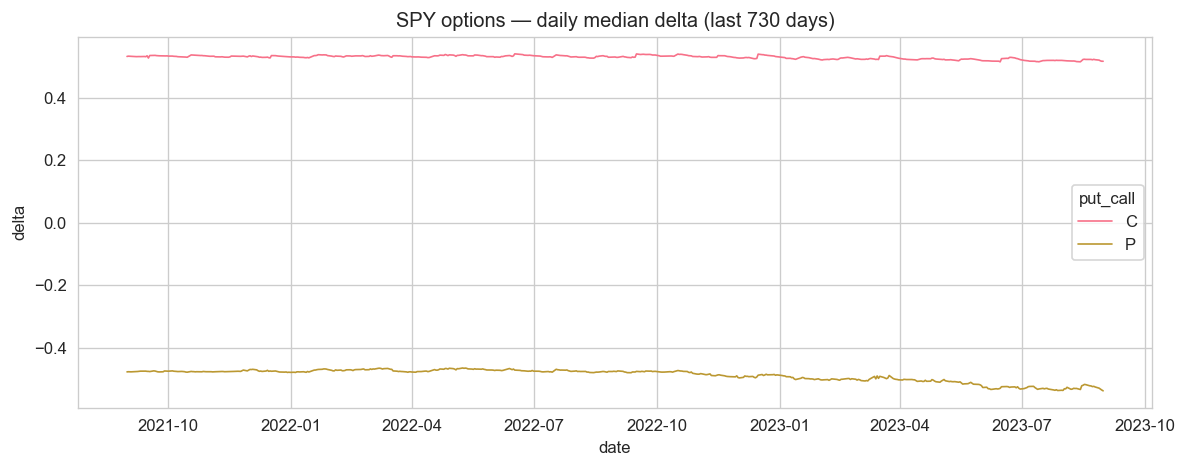

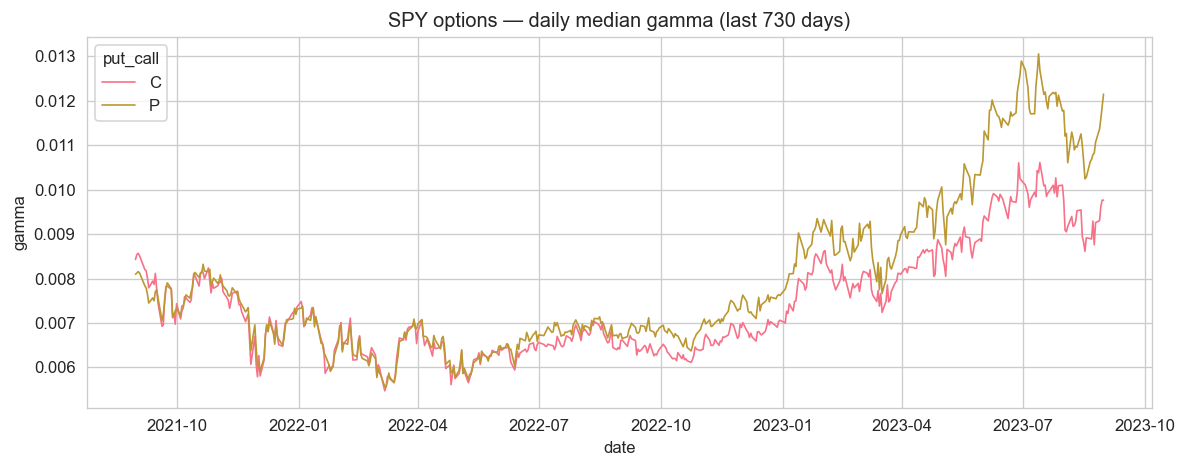

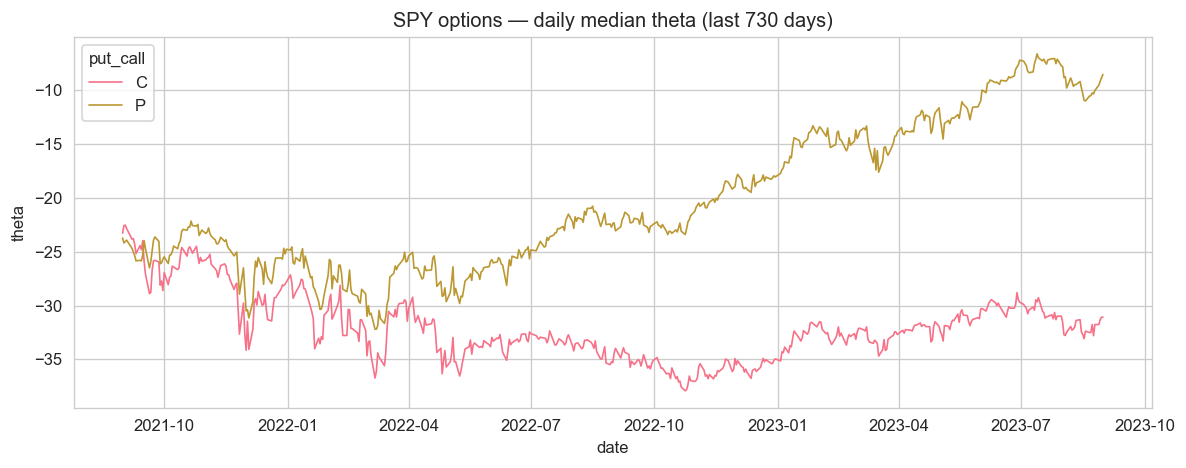

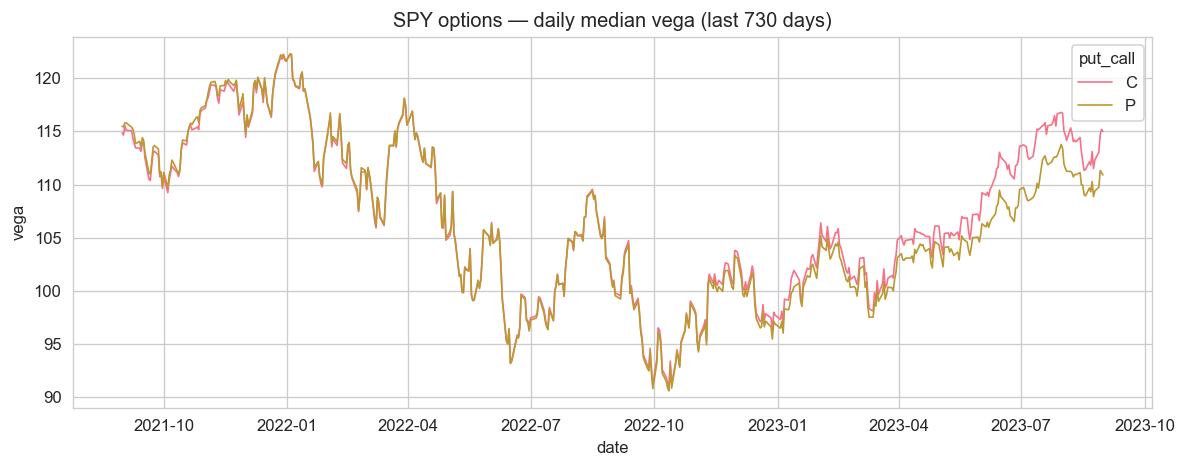

In [28]:
# Reset the color palette specifically for these plots
sns.set_palette("husl")

for col in ["mid", "iv", "delta", "gamma", "theta", "vega"]:
    plt.figure(figsize=(10, 4))
    plt.title(f"SPY options — daily median {col} (last {LAST_N_DAYS} days)")
    sns.lineplot(data=daily, x="date", y=col, hue="put_call", errorbar=None, lw=1)
    plt.xlabel("date"); plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [11]:
opt_spy.head(3)

,date,underlying,put_call,expiry,strike,mid,last,iv,delta,gamma,vega,theta,open_interest,volume
0,2005-01-10,SPY,C,2005-01-20,0.00000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,131377.0
1,2005-01-10,SPY,P,2005-01-20,0.00000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,109647.0
2,2005-01-10,SPY,C,2005-02-09,119.20378,1.622029,1.622029,0.119222,0.506618,0.097998,13.604388,-11.076229,0.0,131377.0


In [12]:
# --- Clean SPY option data ---
print("Before cleaning:", len(opt_spy))

opt_spy_clean = opt_spy.copy()

# Drop rows with missing implied vol or Greeks
cols_to_check = ["iv", "delta", "gamma", "vega"]
opt_spy_clean = opt_spy_clean.dropna(subset=cols_to_check)

# Filter out zero or negative strikes/mid prices
opt_spy_clean = opt_spy_clean[
    (opt_spy_clean["strike"] > 0) &
    (opt_spy_clean["mid"] > 0)
]

# Ensure date is parsed
opt_spy_clean["date"] = pd.to_datetime(opt_spy_clean["date"], errors="coerce")

print("After cleaning:", len(opt_spy_clean))
display(opt_spy_clean.head())

Before cleaning: 103246
After cleaning: 100510


,date,underlying,put_call,expiry,strike,mid,last,iv,delta,gamma,vega,theta,open_interest,volume
2,2005-01-10,SPY,C,2005-02-09,119.203780,1.622029,1.622029,0.119222,0.506618,0.097998,13.604388,-11.076229,0.0,131377.0
3,2005-01-10,SPY,P,2005-02-09,119.203780,1.651591,1.651591,0.120288,-0.499060,0.099202,13.573627,-8.884660,0.0,109647.0
4,2005-01-10,SPY,C,2005-03-11,119.479045,2.329275,2.329275,0.121075,0.509576,0.068224,19.235642,-8.500341,0.0,131377.0
5,2005-01-10,SPY,P,2005-03-11,119.479045,2.397819,2.397819,0.122450,-0.501855,0.070335,19.130987,-5.942738,0.0,109647.0
6,2005-01-10,SPY,C,2005-04-11,119.203046,3.000457,3.000457,0.123830,0.527561,0.056166,23.425184,-7.642386,0.0,131377.0


In [13]:
# Quick range check for key columns
for col in ["iv", "delta", "gamma", "vega", "theta", "mid"]:
    if col in opt_spy_clean.columns:
        print(f"{col:>6} range: {opt_spy_clean[col].min():.4f}  to  {opt_spy_clean[col].max():.4f}")

    iv range: 0.0552  to  0.9896
 delta range: -0.6100  to  0.9000
 gamma range: 0.0026  to  0.4311
  vega range: 0.7547  to  260.3121
 theta range: -292.6890  to  0.9522
   mid range: 0.8001  to  58.8977


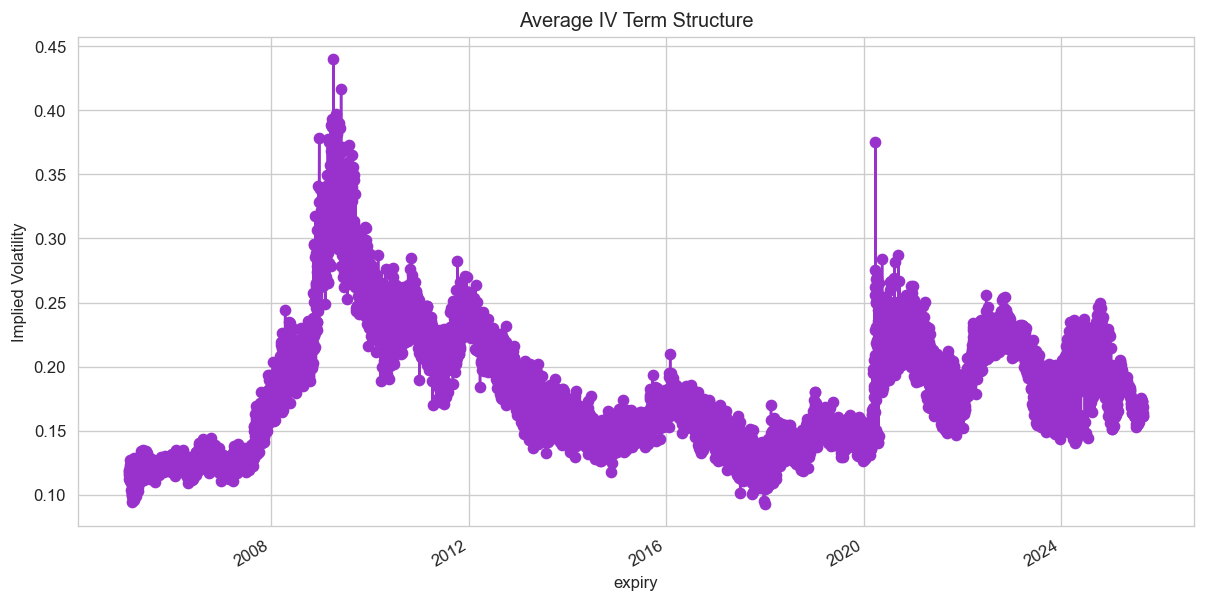

In [14]:
iv_term = opt_spy_clean.groupby("expiry")["iv"].mean().sort_index()
iv_term.plot(marker="o", title="Average IV Term Structure", color = "darkorchid")
plt.ylabel("Implied Volatility")
plt.show()

# Cleaning some datasets

## SPX

In [15]:
from data_pipeline.loaders import load_vol_surface_wrds, load_forward_prices_wrds, load_option_volume_wrds
from data_pipeline.config import ROOT as ROOT_CFG, PROCESSED_DIR, CLEANED, RAW_DIR

panel_fp_spx = RAW_DIR / "GSPC_data.csv"
panel_spx = pd.read_csv(panel_fp_spx)
panel_spx = panel_spx.sort_index()
panel_spx = panel_spx.reset_index()
display(panel_spx.head(3))

fp_market_spx = CLEANED / "market_extended_spx_clean.parquet"
market_spx = pd.read_parquet(fp_market_spx)
market_spx = market_spx.sort_index()
market_spx = market_spx.reset_index()
display(market_spx.head(3))


,index,date,close_gspc,high_gspc,low_gspc,open_gspc,rv_21d
0,0,1950-01-03,16.66,16.66,16.66,16.66,0.106477
1,1,1950-01-04,16.85,16.85,16.85,16.85,0.105440
2,2,1950-01-05,16.93,16.93,16.93,16.93,0.104849


,date,close_spy,close_gspc,vix,rate_10y,hvol_10d,hvol_14d,hvol_30d,hvol_60d,hvol_91d,hvol_122d,hvol_152d,hvol_182d,hvol_273d,hvol_365d,hvol_547d,hvol_730d,hvol_1825d,fwd_front
0,1996-01-04,36.771626,617.700012,13.78,5.65,0.066934,0.06226,0.099637,0.091679,0.088536,0.082083,0.07694,0.078675,0.0823,0.078532,0.08396,0.089418,0.102954,619.154402
1,1996-01-04,36.771626,617.700012,13.78,5.65,0.066934,0.06226,0.099637,0.091679,0.088536,0.082083,0.07694,0.078675,0.0823,0.078532,0.08396,0.089418,0.102954,620.656417
2,1996-01-04,36.771626,617.700012,13.78,5.65,0.066934,0.06226,0.099637,0.091679,0.088536,0.082083,0.07694,0.078675,0.0823,0.078532,0.08396,0.089418,0.102954,621.805572


In [16]:
# --- ensure both 'date' columns are datetime ---
for df in [market_spx, panel_spx]:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

# --- now merge ---
market_spx = market_spx.drop(columns='close_spy')
market_panel_spx = (
    market_spx.merge(panel_spx, on=['date', 'close_gspc'], how='inner')
               .set_index('date')
               .sort_index()
)

display(market_panel_spx.head(3))
print(market_panel_spx.dtypes.head(10))


,close_gspc,vix,rate_10y,hvol_10d,hvol_14d,hvol_30d,hvol_60d,hvol_91d,hvol_122d,hvol_152d,...,hvol_365d,hvol_547d,hvol_730d,hvol_1825d,fwd_front,index,high_gspc,low_gspc,open_gspc,rv_21d
date,,,,,,,,,,,,,,,,,,,,,
1996-01-04,617.700012,13.78,5.65,0.066934,0.06226,0.099637,0.091679,0.088536,0.082083,0.07694,...,0.078532,0.08396,0.089418,0.102954,619.154402,11573,624.48999,613.960022,621.320007,0.125956
1996-01-04,617.700012,13.78,5.65,0.066934,0.06226,0.099637,0.091679,0.088536,0.082083,0.07694,...,0.078532,0.08396,0.089418,0.102954,620.656417,11573,624.48999,613.960022,621.320007,0.125956
1996-01-04,617.700012,13.78,5.65,0.066934,0.06226,0.099637,0.091679,0.088536,0.082083,0.07694,...,0.078532,0.08396,0.089418,0.102954,621.805572,11573,624.48999,613.960022,621.320007,0.125956


close_gspc    float64
vix           float64
rate_10y      float64
hvol_10d      float64
hvol_14d      float64
hvol_30d      float64
hvol_60d      float64
hvol_91d      float64
hvol_122d     float64
hvol_152d     float64
dtype: object


In [17]:
market_panel_spx.columns

Index(['close_gspc', 'vix', 'rate_10y', 'hvol_10d', 'hvol_14d', 'hvol_30d',
       'hvol_60d', 'hvol_91d', 'hvol_122d', 'hvol_152d', 'hvol_182d',
       'hvol_273d', 'hvol_365d', 'hvol_547d', 'hvol_730d', 'hvol_1825d',
       'fwd_front', 'index', 'high_gspc', 'low_gspc', 'open_gspc', 'rv_21d'],
      dtype='object')

## SPY

In [18]:
panel_fp_spy = RAW_DIR / "SPY_data.csv"
panel_spy = pd.read_csv(panel_fp_spy)
panel_spy = panel_spy.sort_index()

fp_market_spy = CLEANED / "market_extended_spy_clean.parquet"
market_spy = pd.read_parquet(fp_market_spy)
market_spy = market_spy.sort_index()
market_spy = market_spy.reset_index()
display(market_spy.head(3))


,date,close_spy,close_gspc,vix,rate_10y,hvol_10d,hvol_14d,hvol_30d,hvol_60d,hvol_91d,hvol_122d,hvol_152d,hvol_182d,hvol_273d,hvol_365d,hvol_547d,hvol_730d,hvol_1825d,fwd_front
0,2005-01-10,80.962646,1190.25,13.23,4.29,0.110306,0.092575,0.083385,0.084841,0.097714,0.10048,0.099316,0.105734,0.110247,0.111598,0.11314,0.138281,0.20419,119.064460
1,2005-01-10,80.962646,1190.25,13.23,4.29,0.110306,0.092575,0.083385,0.084841,0.097714,0.10048,0.099316,0.105734,0.110247,0.111598,0.11314,0.138281,0.20419,119.301194
2,2005-01-10,80.962646,1190.25,13.23,4.29,0.110306,0.092575,0.083385,0.084841,0.097714,0.10048,0.099316,0.105734,0.110247,0.111598,0.11314,0.138281,0.20419,118.986832


In [19]:
# --- ensure both 'date' columns are datetime ---
for df in [market_spy, panel_spy]:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

# --- now merge ---
market_spy = market_spy.drop(columns='close_gspc')
market_panel_spy = (
    market_spy.merge(panel_spy, on=['date', 'close_spy'], how='inner')
               .set_index('date')
               .sort_index()
)

display(market_panel_spy.head(3))
print(market_panel_spy.dtypes.head(10))

,close_spy,vix,rate_10y,hvol_10d,hvol_14d,hvol_30d,hvol_60d,hvol_91d,hvol_122d,hvol_152d,...,hvol_273d,hvol_365d,hvol_547d,hvol_730d,hvol_1825d,fwd_front,high_spy,low_spy,open_spy,rv_21d
date,,,,,,,,,,,,,,,,,,,,,
2005-01-21,79.452278,14.36,4.16,0.125623,0.118257,0.097512,0.089121,0.09803,0.10453,0.099892,...,0.108384,0.112556,0.112634,0.137524,0.203975,116.787588,80.282316,79.363833,80.139442,0.094577
2005-01-21,79.452278,14.36,4.16,0.125623,0.118257,0.097512,0.089121,0.09803,0.10453,0.099892,...,0.108384,0.112556,0.112634,0.137524,0.203975,117.001989,80.282316,79.363833,80.139442,0.094577
2005-01-21,79.452278,14.36,4.16,0.125623,0.118257,0.097512,0.089121,0.09803,0.10453,0.099892,...,0.108384,0.112556,0.112634,0.137524,0.203975,116.706210,80.282316,79.363833,80.139442,0.094577


close_spy    float64
vix          float64
rate_10y     float64
hvol_10d     float64
hvol_14d     float64
hvol_30d     float64
hvol_60d     float64
hvol_91d     float64
hvol_122d    float64
hvol_152d    float64
dtype: object


## Exporting

In [20]:
market_panel_spy.to_parquet(CLEANED / "market_plus_panel_spy.parquet")
market_panel_spx.to_parquet(CLEANED / "market_plus_panel_spx.parquet")

# Building the large zip files

In [21]:
import sys
from pathlib import Path

NB   = Path.cwd()
ROOT = NB.parent
SRC  = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from data_pipeline.config import ROOT, RAW_SPX, RAW_SPY  

print("CWD :", Path.cwd())
print("ROOT:", ROOT)
print("SPX dir:", RAW_SPX, "exists?", RAW_SPX.exists())
print("SPY dir:", RAW_SPY, "exists?", RAW_SPY.exists())

def pick_csv(dirpath: Path) -> Path:
    files = sorted(dirpath.glob("*.csv"))
    if not files:
        raise FileNotFoundError(f"No CSVs in {dirpath}. Check the path or LFS checkout.")
    # choose the largest file if multiple
    return max(files, key=lambda p: p.stat().st_size)

SPX_FILE = pick_csv(RAW_SPX)
SPY_FILE = pick_csv(RAW_SPY)
SPX_FILE, SPY_FILE


CWD : /Users/ya/Desktop/deep-hedging-rl/notebooks
ROOT: /Users/ya/Desktop/deep-hedging-rl
SPX dir: /Users/ya/Desktop/deep-hedging-rl/data/raw/options_spx exists? True
SPY dir: /Users/ya/Desktop/deep-hedging-rl/data/raw/options_spy exists? True


(PosixPath('/Users/ya/Desktop/deep-hedging-rl/data/raw/options_spx/l8au9t4q1ij3lofm.csv'),
 PosixPath('/Users/ya/Desktop/deep-hedging-rl/data/raw/options_spy/nwymczfl7n3h33rg.csv'))

In [22]:
# --- config paths from your data_pipeline.config ---
from pathlib import Path
from data_pipeline.config import ROOT, RAW_SPX, RAW_SPY
from data_pipeline.clean_data import csv_to_parquet_parts_om, pick_csv, load_options_dir, qc

OUT_DIR = ROOT / "data" / "processed" / "options_parquet"
(OUT_DIR / "SPX").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "SPY").mkdir(parents=True, exist_ok=True)

SPX_FILE = pick_csv(RAW_SPX)
SPY_FILE = pick_csv(RAW_SPY)

csv_to_parquet_parts_om(SPX_FILE, OUT_DIR / "SPX")
csv_to_parquet_parts_om(SPY_FILE, OUT_DIR / "SPY")


In [23]:
import pyarrow.dataset as ds
import pandas as pd
from pathlib import Path

spx = load_options_dir(OUT_DIR / "SPX")
spy = load_options_dir(OUT_DIR / "SPY")


In [24]:
KEY = ["date","underlying","put_call","expiry","strike"]
spx = spx.sort_values(KEY).drop_duplicates(KEY, keep="last")
spy = spy.sort_values(KEY).drop_duplicates(KEY, keep="last")

qc(spx, "SPX"); qc(spy, "SPY")

dates_spx = set(spx["date"]); dates_spy = set(spy["date"])
print("Shared trading days:", len(dates_spx & dates_spy))


[SPX] rows=32,190,466  1996-01-04→2023-08-31
  neg_spread%=0.000%  zero_spread%=0.000%  iv>5%=0.039%
[SPY] rows=20,357,886  2005-01-10→2023-08-31
  neg_spread%=0.014%  zero_spread%=0.016%  iv>5%=0.025%
Shared trading days: 4693


In [25]:
from pathlib import Path
import pandas as pd
import pyarrow.parquet as pq

from data_pipeline.clean_data import _read_part_selective, _clean_chunk, clean_options_dir

# --- paths ---
from data_pipeline.config import ROOT, PROCESSED_DIR

spx_clean_dir = clean_options_dir("SPX", strict_liquidity=False)
spy_clean_dir = clean_options_dir("SPY", strict_liquidity=False)
spx_clean_dir, spy_clean_dir

(PosixPath('/Users/ya/Desktop/deep-hedging-rl/data/processed/cleaned/SPX'),
 PosixPath('/Users/ya/Desktop/deep-hedging-rl/data/processed/cleaned/SPY'))

In [26]:
import pyarrow.parquet as pq
from data_pipeline.clean_data import check_nans_in_parquet

# Check for NaNs in SPX and SPY parquet files
print("Checking SPX files for NaNs:")
check_nans_in_parquet(spx_clean_dir)

print("\nChecking SPY files for NaNs:")
check_nans_in_parquet(spy_clean_dir)

Checking SPX files for NaNs:
File: part_0001.parquet
Series([], dtype: int64)
----------------------------------------
File: part_0002.parquet
Series([], dtype: int64)
----------------------------------------
File: part_0003.parquet
Series([], dtype: int64)
----------------------------------------
File: part_0004.parquet
Series([], dtype: int64)
----------------------------------------
File: part_0005.parquet
Series([], dtype: int64)
----------------------------------------
File: part_0006.parquet
Series([], dtype: int64)
----------------------------------------
File: part_0007.parquet
theta    1
dtype: int64
----------------------------------------
File: part_0008.parquet
Series([], dtype: int64)
----------------------------------------
File: part_0009.parquet
Series([], dtype: int64)
----------------------------------------
File: part_0010.parquet
Series([], dtype: int64)
----------------------------------------
File: part_0011.parquet
Series([], dtype: int64)
-----------------------